## Test Mesh

This notebook tests the implementation and main features of the mesh class

In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize

import camb as camb

In [ ]:
sys.path.insert(0,'/home/emaragliano/Work/Projects/Dottorato/baorecon/')
print('Current working directory:', os.getcwd())
sys.path

Current working directory: /mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/tests


['/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/',
 '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/tests',
 '/home/emaragliano/Pylians/library/build/lib.linux-x86_64-2.7',
 '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python310.zip',
 '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10',
 '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/lib-dynload',
 '',
 '/home/emaragliano/.local/lib/python3.10/site-packages',
 '/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages',
 '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction',
 '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/Recon_challenge',
 '/mnt/project_mnt/home_fs/emaragliano/Work/Projects/MyThesisLib_dev']

In [3]:
from glob import glob

In [4]:
from zeldareco.mock_generator import generate_gaussian_map, generate_lognormal_map
from zeldareco.mesh.mesh import Mesh as Mesh

In [5]:
n_mesh = 512
box_size = 1024  # Mpc/h

cell_size = int(box_size / n_mesh)
print('cell_size:', cell_size)

LOS = 'z'

redshift = 1.0

cell_size: 2


## Check the LOS

### los along z

In [6]:
mesh_obj_z = Mesh(los=LOS,
                      nmesh=n_mesh, 
                      boxsize=box_size, 
                      boxcentre=[box_size//2, box_size//2, box_size//2]
                      )

mesh_obj_z.print_info()

X,Y,Z = mesh_obj_z.xmesh[...,0], mesh_obj_z.xmesh[...,1], mesh_obj_z.xmesh[...,2]
los = mesh_obj_z.los_versor

2025-11-24 16:03:11,428 - zeldareco.mesh.mesh - INFO - Mesh Information:
2025-11-24 16:03:11,429 - zeldareco.mesh.mesh - INFO - Boxsize: 1024 Mpc/h
2025-11-24 16:03:11,430 - zeldareco.mesh.mesh - INFO - Number of grid points: 512
2025-11-24 16:03:11,430 - zeldareco.mesh.mesh - INFO - Cell size: 2.0 Mpc/h
2025-11-24 16:03:11,431 - zeldareco.mesh.mesh - INFO - Boxcentre: [512. 512. 512.]
2025-11-24 16:03:11,431 - zeldareco.mesh.mesh - INFO - Line-of-sight: z


In [7]:
plot_every = 30

/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/matplotlib/quiver.py:649: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/matplotlib/quiver.py:649: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


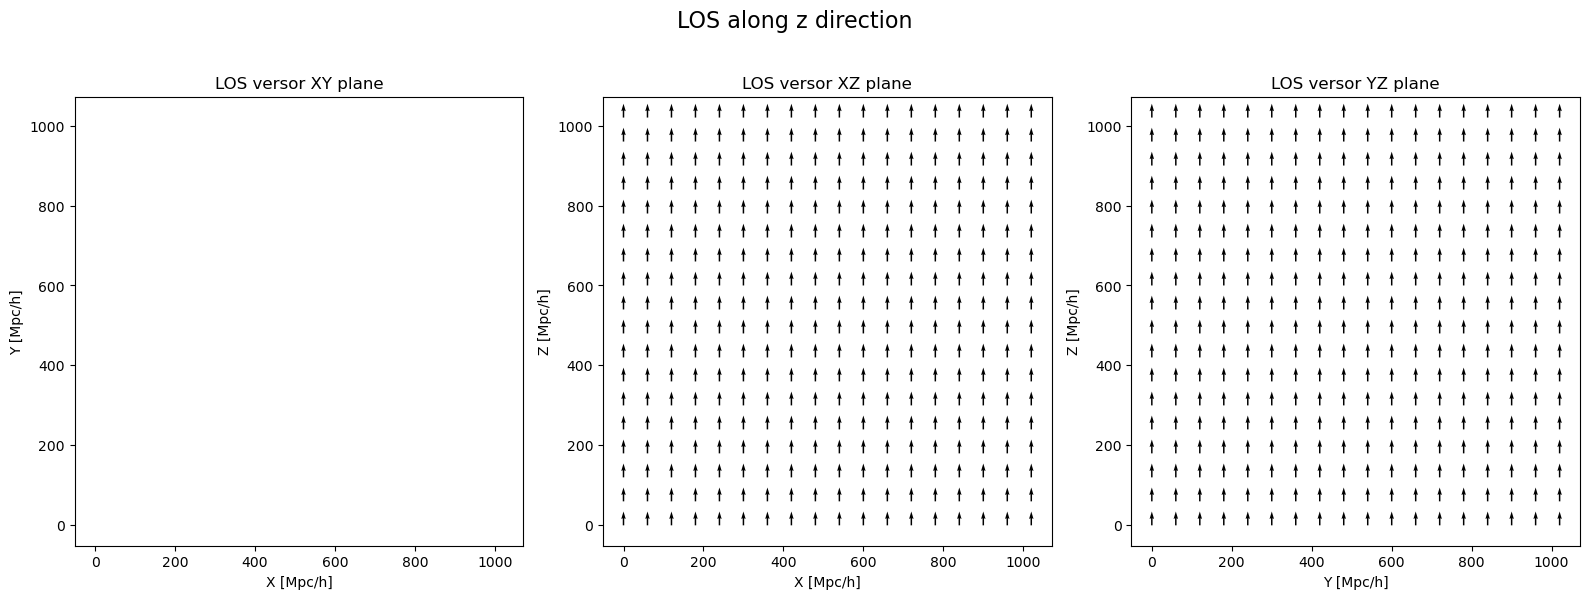

In [8]:
# plot the LOS versor XY, XZ, YZ planes
fig, axs = plt.subplots(1, 3, figsize=(16,6))

im0 = axs[0].quiver(X[::plot_every, ::plot_every, n_mesh//2], Y[::plot_every, ::plot_every, n_mesh//2],
                     los[::plot_every, ::plot_every, n_mesh//2, 0],
                     los[::plot_every, ::plot_every, n_mesh//2, 1])
axs[0].set_title('LOS versor XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')

im1 = axs[1].quiver(X[::plot_every, n_mesh//2, ::plot_every], Z[::plot_every, n_mesh//2, ::plot_every],
                     los[::plot_every, n_mesh//2, ::plot_every, 0],
                     los[::plot_every, n_mesh//2, ::plot_every, 2])
axs[1].set_title('LOS versor XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')

im2 = axs[2].quiver(Y[n_mesh//2, ::plot_every, ::plot_every], Z[n_mesh//2, ::plot_every, ::plot_every],
                     los[n_mesh//2, ::plot_every, ::plot_every, 1],
                     los[n_mesh//2, ::plot_every, ::plot_every, 2])
axs[2].set_title('LOS versor YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')

for ax in axs:
    ax.set_aspect('equal')
    
plt.tight_layout()
plt.suptitle('LOS along z direction', y=1.02, fontsize=16)
plt.show()



### los along x

In [9]:
mesh_obj_x = Mesh(los='x',
                      nmesh=n_mesh, 
                      boxsize=box_size, 
                      boxcentre=[box_size//2, box_size//2, box_size//2]
                      )

mesh_obj_x.print_info()

X,Y,Z = mesh_obj_x.xmesh[...,0], mesh_obj_x.xmesh[...,1], mesh_obj_x.xmesh[...,2]
los = mesh_obj_x.los_versor

2025-11-24 16:03:21,526 - zeldareco.mesh.mesh - INFO - Mesh Information:
2025-11-24 16:03:21,527 - zeldareco.mesh.mesh - INFO - Boxsize: 1024 Mpc/h
2025-11-24 16:03:21,527 - zeldareco.mesh.mesh - INFO - Number of grid points: 512
2025-11-24 16:03:21,528 - zeldareco.mesh.mesh - INFO - Cell size: 2.0 Mpc/h
2025-11-24 16:03:21,528 - zeldareco.mesh.mesh - INFO - Boxcentre: [512. 512. 512.]
2025-11-24 16:03:21,529 - zeldareco.mesh.mesh - INFO - Line-of-sight: x


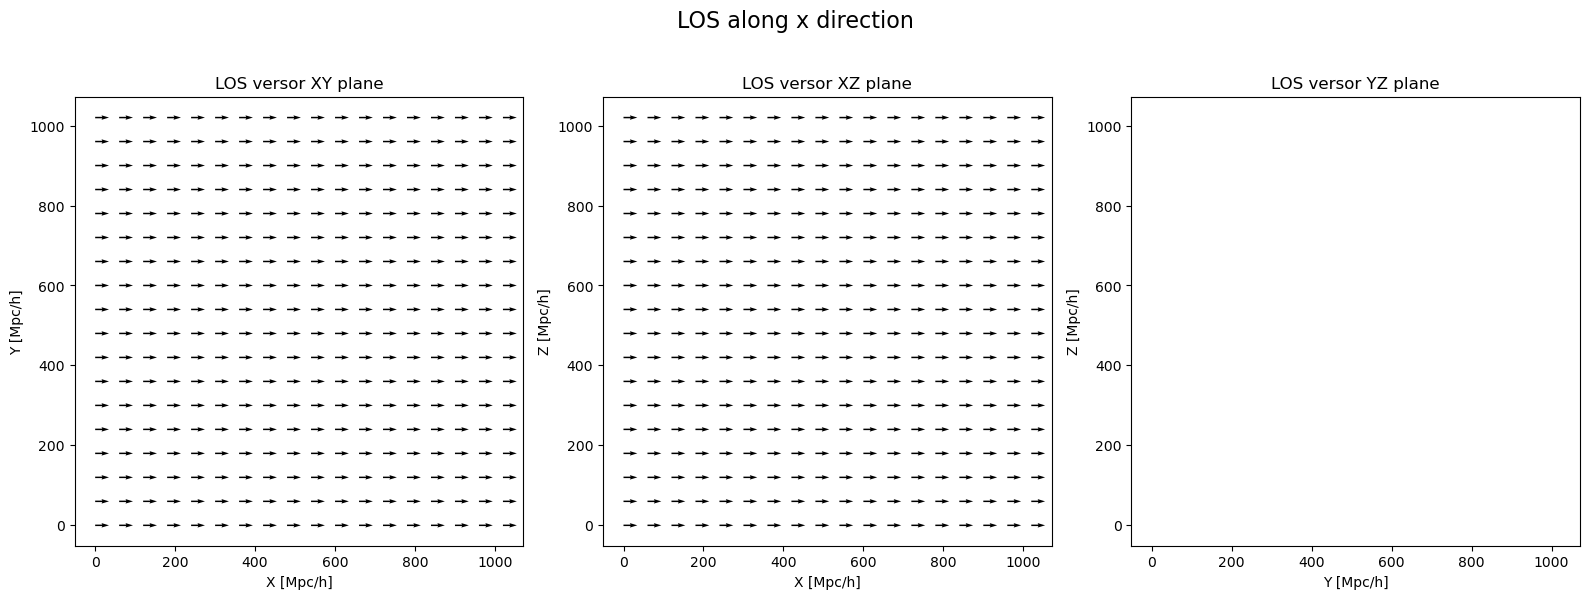

In [10]:
# plot the LOS versor XY, XZ, YZ planes
fig, axs = plt.subplots(1, 3, figsize=(16,6))

im0 = axs[0].quiver(X[::plot_every, ::plot_every, n_mesh//2], Y[::plot_every, ::plot_every, n_mesh//2],
                     los[::plot_every, ::plot_every, n_mesh//2, 0],
                     los[::plot_every, ::plot_every, n_mesh//2, 1])
axs[0].set_title('LOS versor XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')

im1 = axs[1].quiver(X[::plot_every, n_mesh//2, ::plot_every], Z[::plot_every, n_mesh//2, ::plot_every],
                     los[::plot_every, n_mesh//2, ::plot_every, 0],
                     los[::plot_every, n_mesh//2, ::plot_every, 2])
axs[1].set_title('LOS versor XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')

im2 = axs[2].quiver(Y[n_mesh//2, ::plot_every, ::plot_every], Z[n_mesh//2, ::plot_every, ::plot_every],
                     los[n_mesh//2, ::plot_every, ::plot_every, 1],
                     los[n_mesh//2, ::plot_every, ::plot_every, 2])
axs[2].set_title('LOS versor YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')

for ax in axs:
    ax.set_aspect('equal')
    
plt.tight_layout()
plt.suptitle('LOS along x direction', y=1.02, fontsize=16)
plt.show()



### los along y

In [11]:
mesh_obj_y = Mesh(los='y',
                      nmesh=n_mesh, 
                      boxsize=box_size, 
                      boxcentre=[box_size//2, box_size//2, box_size//2]
                      )

mesh_obj_y.print_info()

X,Y,Z = mesh_obj_y.xmesh[...,0], mesh_obj_y.xmesh[...,1], mesh_obj_y.xmesh[...,2]
los = mesh_obj_y.los_versor

2025-11-24 16:03:32,289 - zeldareco.mesh.mesh - INFO - Mesh Information:
2025-11-24 16:03:32,289 - zeldareco.mesh.mesh - INFO - Boxsize: 1024 Mpc/h
2025-11-24 16:03:32,290 - zeldareco.mesh.mesh - INFO - Number of grid points: 512
2025-11-24 16:03:32,290 - zeldareco.mesh.mesh - INFO - Cell size: 2.0 Mpc/h
2025-11-24 16:03:32,291 - zeldareco.mesh.mesh - INFO - Boxcentre: [512. 512. 512.]
2025-11-24 16:03:32,291 - zeldareco.mesh.mesh - INFO - Line-of-sight: y


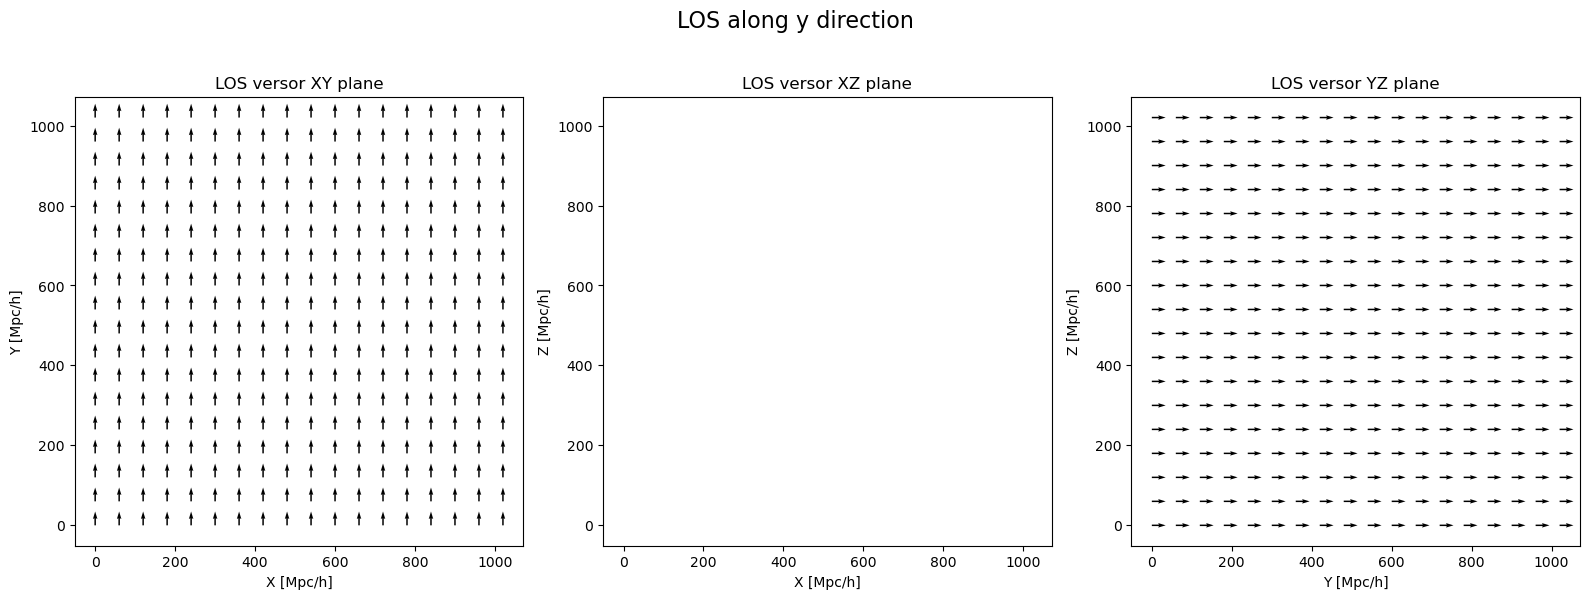

In [12]:
# plot the LOS versor XY, XZ, YZ planes
fig, axs = plt.subplots(1, 3, figsize=(16,6))

im0 = axs[0].quiver(X[::plot_every, ::plot_every, n_mesh//2], Y[::plot_every, ::plot_every, n_mesh//2],
                     los[::plot_every, ::plot_every, n_mesh//2, 0],
                     los[::plot_every, ::plot_every, n_mesh//2, 1])
axs[0].set_title('LOS versor XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')

im1 = axs[1].quiver(X[::plot_every, n_mesh//2, ::plot_every], Z[::plot_every, n_mesh//2, ::plot_every],
                     los[::plot_every, n_mesh//2, ::plot_every, 0],
                     los[::plot_every, n_mesh//2, ::plot_every, 2])
axs[1].set_title('LOS versor XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')

im2 = axs[2].quiver(Y[n_mesh//2, ::plot_every, ::plot_every], Z[n_mesh//2, ::plot_every, ::plot_every],
                     los[n_mesh//2, ::plot_every, ::plot_every, 1],
                     los[n_mesh//2, ::plot_every, ::plot_every, 2])
axs[2].set_title('LOS versor YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')

for ax in axs:
    ax.set_aspect('equal')
    
plt.tight_layout()
plt.suptitle('LOS along y direction', y=1.02, fontsize=16)
plt.show()



### Local LOS

In [13]:
mesh_obj_local = Mesh(los=None,
                      nmesh=n_mesh, 
                      boxsize=box_size, 
                      boxcentre=[box_size//2, box_size//2, box_size//2]
                      )

mesh_obj_local.print_info()

X,Y,Z = mesh_obj_local.xmesh[...,0], mesh_obj_local.xmesh[...,1], mesh_obj_local.xmesh[...,2]
los = mesh_obj_local.los_versor

2025-11-24 16:03:50,330 - zeldareco.mesh.mesh - INFO - Mesh Information:
2025-11-24 16:03:50,331 - zeldareco.mesh.mesh - INFO - Boxsize: 1024 Mpc/h
2025-11-24 16:03:50,331 - zeldareco.mesh.mesh - INFO - Number of grid points: 512
2025-11-24 16:03:50,331 - zeldareco.mesh.mesh - INFO - Cell size: 2.0 Mpc/h
2025-11-24 16:03:50,332 - zeldareco.mesh.mesh - INFO - Boxcentre: [512. 512. 512.]
2025-11-24 16:03:50,333 - zeldareco.mesh.mesh - INFO - Line-of-sight: None


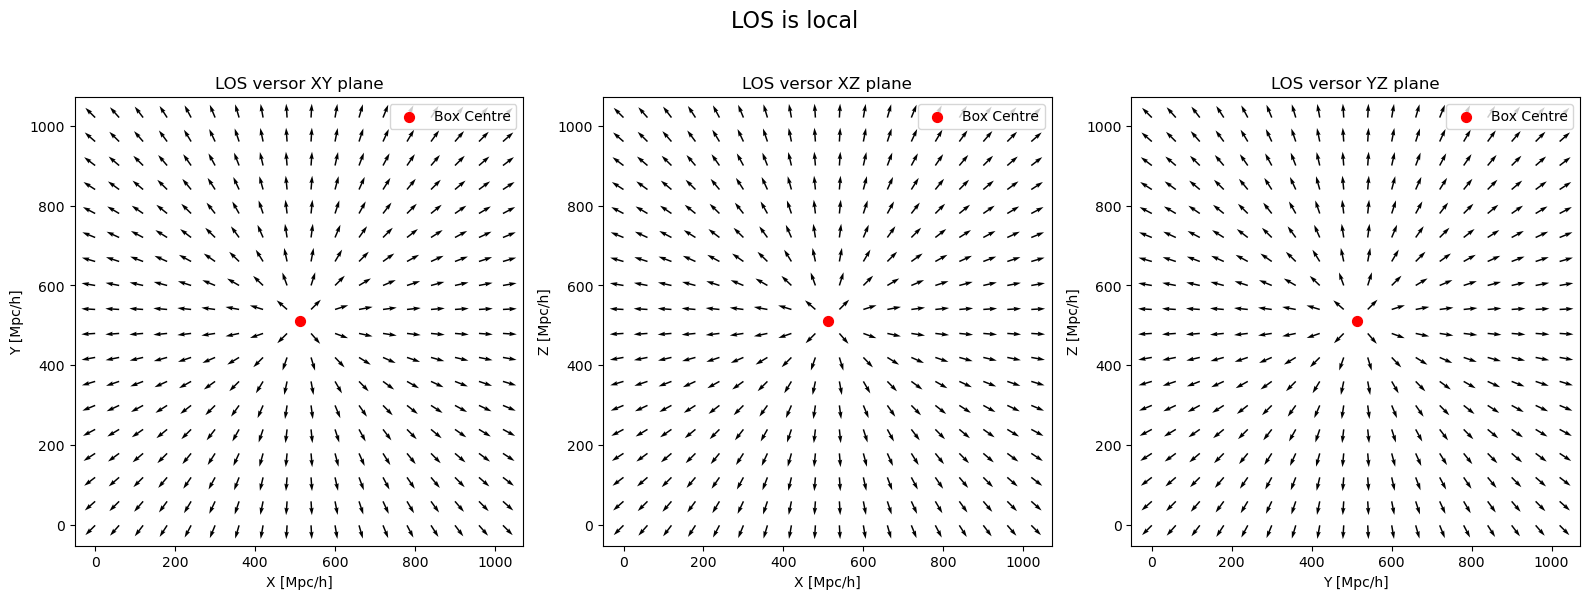

In [14]:
# plot the LOS versor XY, XZ, YZ planes
fig, axs = plt.subplots(1, 3, figsize=(16,6))

im0 = axs[0].quiver(X[::plot_every, ::plot_every, n_mesh//2], Y[::plot_every, ::plot_every, n_mesh//2],
                     los[::plot_every, ::plot_every, n_mesh//2, 0],
                     los[::plot_every, ::plot_every, n_mesh//2, 1])
axs[0].set_title('LOS versor XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')

im1 = axs[1].quiver(X[::plot_every, n_mesh//2, ::plot_every], Z[::plot_every, n_mesh//2, ::plot_every],
                     los[::plot_every, n_mesh//2, ::plot_every, 0],
                     los[::plot_every, n_mesh//2, ::plot_every, 2])
axs[1].set_title('LOS versor XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')

im2 = axs[2].quiver(Y[n_mesh//2, ::plot_every, ::plot_every], Z[n_mesh//2, ::plot_every, ::plot_every],
                     los[n_mesh//2, ::plot_every, ::plot_every, 1],
                     los[n_mesh//2, ::plot_every, ::plot_every, 2])
axs[2].set_title('LOS versor YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')

for ax in axs:
    ax.set_aspect('equal')
    ax.scatter(box_size/2, box_size/2, color='red', s=50, label='Box Centre')
    ax.legend()

plt.tight_layout()
plt.suptitle('LOS is local', y=1.02, fontsize=16)
plt.show()



## Projection

In [15]:
# define a vector field
vector_field = np.zeros((n_mesh, n_mesh, n_mesh, 3))
vector_field[...,2] = 10
vector_field[...,1] = 0 
vector_field[...,0] = 0


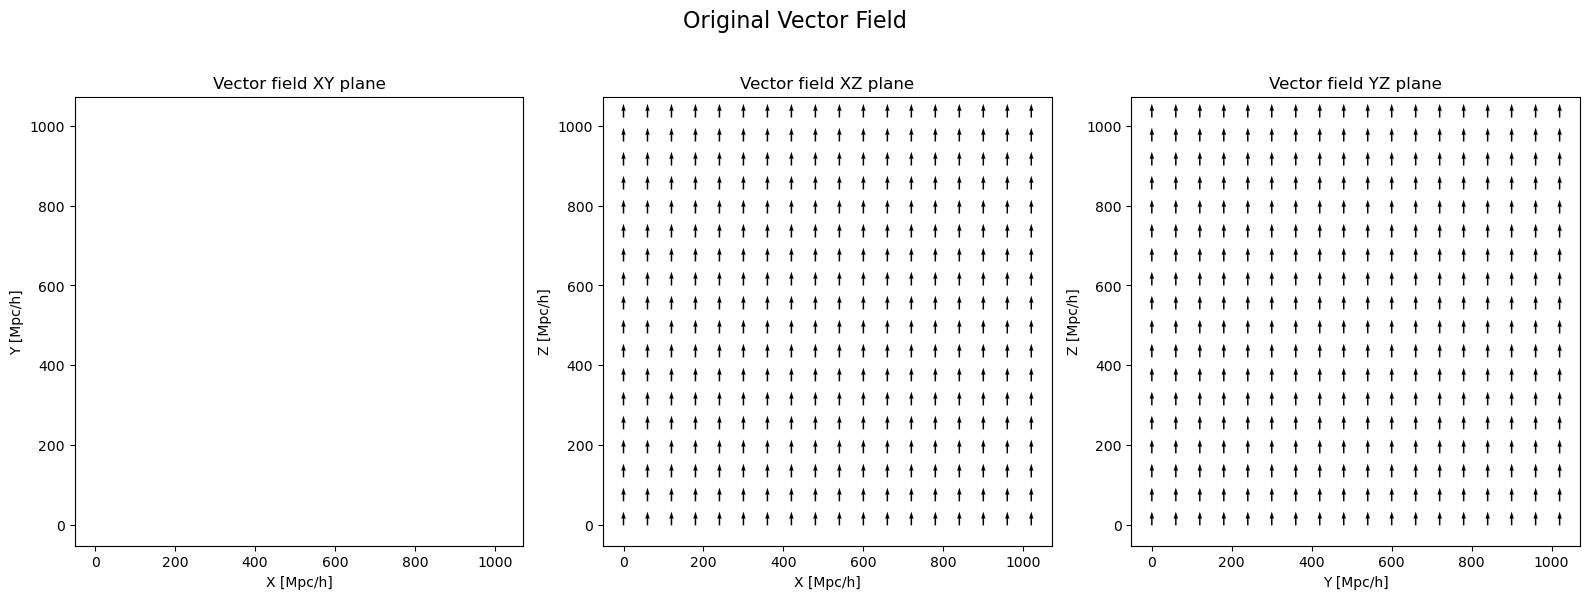

In [16]:
# plot the vector field XY, XZ, YZ planes

fig, axs = plt.subplots(1, 3, figsize=(16,6))
im0 = axs[0].quiver(X[::plot_every, ::plot_every, n_mesh//2], Y[::plot_every, ::plot_every, n_mesh//2],
                     vector_field[::plot_every, ::plot_every, n_mesh//2, 0],
                     vector_field[::plot_every, ::plot_every, n_mesh//2, 1])
axs[0].set_title('Vector field XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')
im1 = axs[1].quiver(X[::plot_every, n_mesh//2, ::plot_every], Z[::plot_every, n_mesh//2, ::plot_every],
                     vector_field[::plot_every, n_mesh//2, ::plot_every, 0],
                     vector_field[::plot_every, n_mesh//2, ::plot_every, 2])
axs[1].set_title('Vector field XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')
im2 = axs[2].quiver(Y[n_mesh//2, ::plot_every, ::plot_every], Z[n_mesh//2, ::plot_every, ::plot_every],
                     vector_field[n_mesh//2, ::plot_every, ::plot_every, 1],
                     vector_field[n_mesh//2, ::plot_every, ::plot_every, 2])
axs[2]. set_title('Vector field YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')  
for ax in axs:
    ax.set_aspect('equal')
plt.tight_layout()
plt.suptitle('Original Vector Field', y=1.02, fontsize=16)
plt.show()

Project along the radial versor

In [17]:
vector_field_parallel_radial = mesh_obj_local.get_parallel_component(vector_field)

In [18]:
plot_every = 30
mid = n_mesh // 4

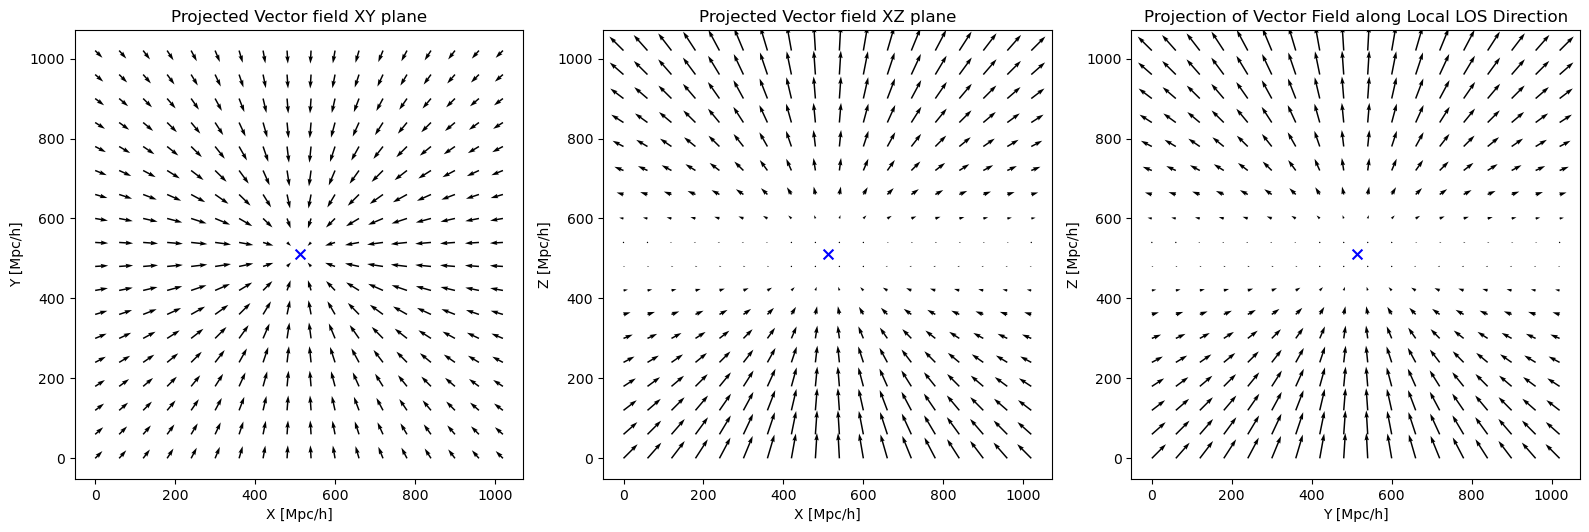

In [19]:
# plot the projected vector field XY, XZ, YZ planes
fig, axs = plt.subplots(1, 3, figsize=(16,6))
im0 = axs[0].quiver(X[::plot_every, ::plot_every, mid], Y[::plot_every, ::plot_every, mid],
                     vector_field_parallel_radial[::plot_every, ::plot_every, mid, 0],
                     vector_field_parallel_radial[::plot_every, ::plot_every, mid, 1])
axs[0].set_title('Projected Vector field XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')
im1 = axs[1].quiver(X[::plot_every, mid, ::plot_every], Z[::plot_every, mid, ::plot_every],
                     vector_field_parallel_radial[::plot_every, mid, ::plot_every, 0],
                     vector_field_parallel_radial[::plot_every, mid, ::plot_every, 2])
axs[1].set_title('Projected Vector field XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')
im2 = axs[2].quiver(Y[mid, ::plot_every, ::plot_every], Z[mid, ::plot_every, ::plot_every],
                     vector_field_parallel_radial[mid, ::plot_every, ::plot_every, 1],
                     vector_field_parallel_radial[mid, ::plot_every, ::plot_every, 2])
axs[2]. set_title('Projected Vector field YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')  
for ax in axs:
    ax.set_aspect('equal')

# Mark the origin
axs[0].scatter(mesh_obj_local.boxcentre[0], mesh_obj_local.boxcentre[1], marker='x', color='blue', s=50, label='Origin')
axs[1].scatter(mesh_obj_local.boxcentre[0], mesh_obj_local.boxcentre[2], marker='x', color='blue', s=50)
axs[2].scatter(mesh_obj_local.boxcentre[1], mesh_obj_local.boxcentre[2], marker='x', color='blue', s=50)

plt.title('Projection of Vector Field along Local LOS Direction')
plt.tight_layout()
plt.show()


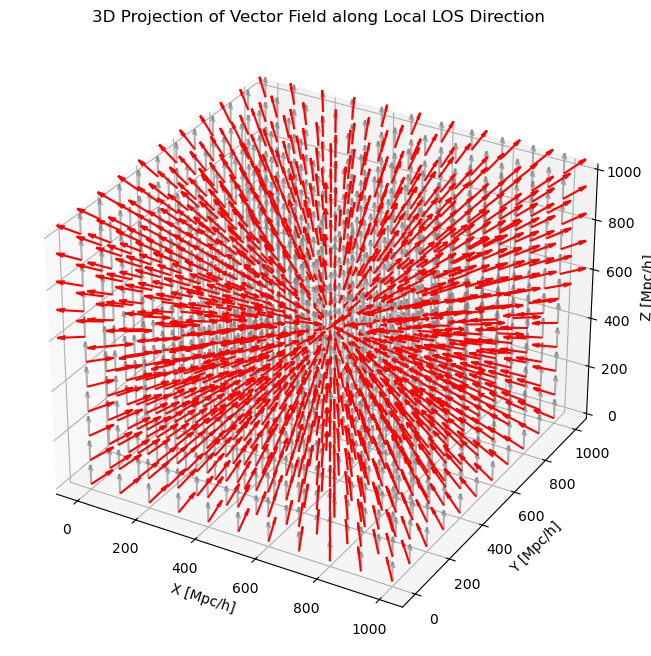

In [20]:
# plot the projected field in 3D
plot_every = 50
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X[::plot_every, ::plot_every, ::plot_every], 
          Y[::plot_every, ::plot_every, ::plot_every], 
          Z[::plot_every, ::plot_every, ::plot_every],
          vector_field_parallel_radial[::plot_every, ::plot_every, ::plot_every, 0],
          vector_field_parallel_radial[::plot_every, ::plot_every, ::plot_every, 1],
          vector_field_parallel_radial[::plot_every, ::plot_every, ::plot_every, 2],
          length=80, normalize=True, color='r')

ax.quiver(X[::plot_every, ::plot_every, ::plot_every], 
          Y[::plot_every, ::plot_every, ::plot_every], 
          Z[::plot_every, ::plot_every, ::plot_every],
          vector_field[::plot_every, ::plot_every, ::plot_every, 0],
          vector_field[::plot_every, ::plot_every, ::plot_every, 1],
          vector_field[::plot_every, ::plot_every, ::plot_every, 2],
          length=80, normalize=True, color='grey', alpha=0.6)

ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_zlabel('Z [Mpc/h]')
ax.set_title('3D Projection of Vector Field along Local LOS Direction')
plt.show()

### Project along z

In [21]:
vector_field_parallel = mesh_obj_z.get_parallel_component(vector_field)

In [22]:
mesh_obj_z.los_versor[0,0,0]

array([0., 0., 1.], dtype=float32)

/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/matplotlib/quiver.py:649: RuntimeWarning: divide by zero encountered in scalar divide
  length = a * (widthu_per_lenu / (self.scale * self.width))
/farmdisk1/emaragliano/miniconda3/envs/BAOFit/lib/python3.10/site-packages/matplotlib/quiver.py:649: RuntimeWarning: invalid value encountered in multiply
  length = a * (widthu_per_lenu / (self.scale * self.width))


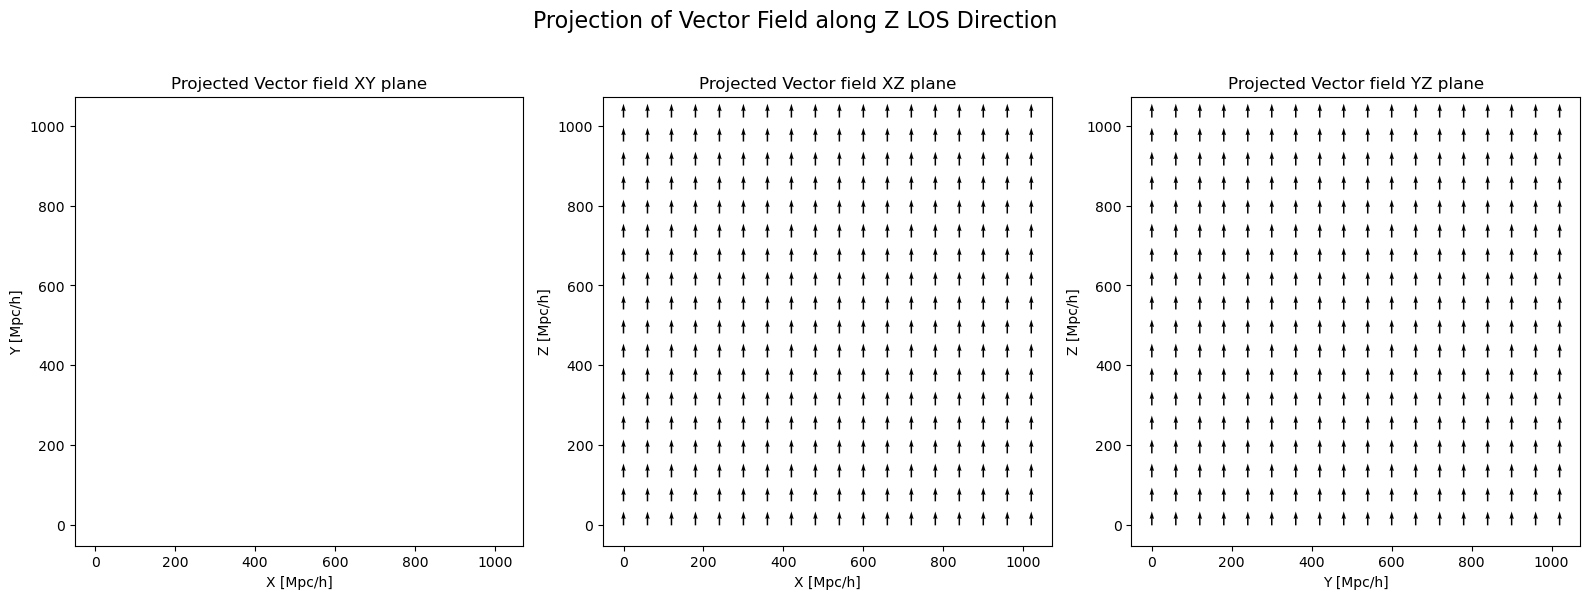

In [23]:
# plot the 3 projections again to compare
plot_every = 30
mid = n_mesh // 4

# plot the projected vector field XY, XZ, YZ planes
fig, axs = plt.subplots(1, 3, figsize=(16,6))
im0 = axs[0].quiver(X[::plot_every, ::plot_every, mid], 
                     Y[::plot_every, ::plot_every, mid],    
                        vector_field_parallel[::plot_every, ::plot_every, mid, 0],
                        vector_field_parallel[::plot_every, ::plot_every, mid, 1])
axs[0].set_title('Projected Vector field XY plane')
axs[0].set_xlabel('X [Mpc/h]')
axs[0].set_ylabel('Y [Mpc/h]')

im1 = axs[1].quiver(X[::plot_every, mid, ::plot_every], 
                     Z[::plot_every, mid, ::plot_every],
                        vector_field_parallel[::plot_every, mid, ::plot_every, 0],
                        vector_field_parallel[::plot_every, mid, ::plot_every, 2])
axs[1].set_title('Projected Vector field XZ plane')
axs[1].set_xlabel('X [Mpc/h]')
axs[1].set_ylabel('Z [Mpc/h]')

im2 = axs[2].quiver(Y[mid, ::plot_every, ::plot_every], 
                     Z[mid, ::plot_every, ::plot_every],
                        vector_field_parallel[mid, ::plot_every, ::plot_every, 1],
                        vector_field_parallel[mid, ::plot_every, ::plot_every, 2])

axs[2]. set_title('Projected Vector field YZ plane')
axs[2].set_xlabel('Y [Mpc/h]')
axs[2].set_ylabel('Z [Mpc/h]')
for ax in axs:
    ax.set_aspect('equal')
plt.tight_layout()
plt.suptitle('Projection of Vector Field along Z LOS Direction', y=1.02, fontsize=16)
plt.show()  

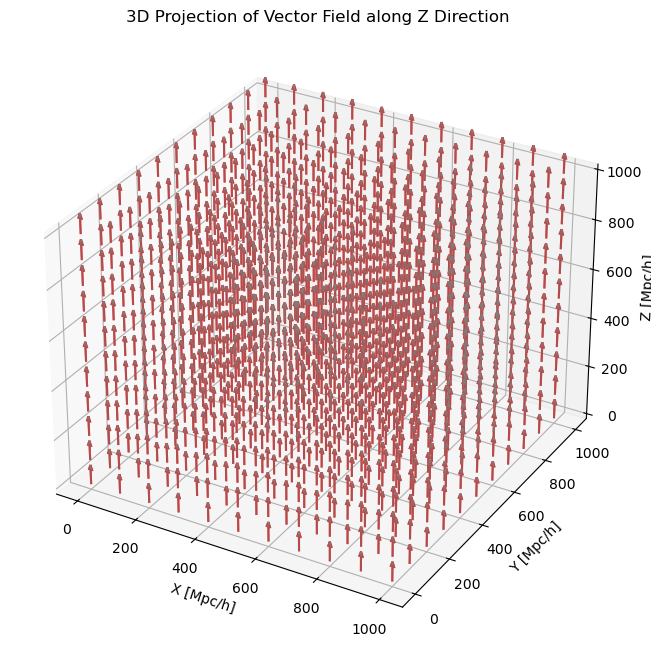

In [24]:
# plot the projected vectro field in 3D
plot_every = 50
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
ax.quiver(X[::plot_every, ::plot_every, ::plot_every], 
          Y[::plot_every, ::plot_every, ::plot_every], 
          Z[::plot_every, ::plot_every, ::plot_every],
          vector_field_parallel[::plot_every, ::plot_every, ::plot_every, 0],
          vector_field_parallel[::plot_every, ::plot_every, ::plot_every, 1],
          vector_field_parallel[::plot_every, ::plot_every, ::plot_every, 2],
          length=80, normalize=True, color='r')

ax.quiver(X[::plot_every, ::plot_every, ::plot_every], 
          Y[::plot_every, ::plot_every, ::plot_every], 
          Z[::plot_every, ::plot_every, ::plot_every],
          vector_field[::plot_every, ::plot_every, ::plot_every, 0],
          vector_field[::plot_every, ::plot_every, ::plot_every, 1],
          vector_field[::plot_every, ::plot_every, ::plot_every, 2],
          length=80, normalize=True, color='grey', alpha=0.6)

ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_zlabel('Z [Mpc/h]')
ax.set_title('3D Projection of Vector Field along Z Direction')
plt.show()